In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

In [4]:
# STUDY_NRS = ["s214696", "s224184", "s224223"]
STUDY_NRS = ["s224184"]

MALE_END = "face_00.5.png"    # the adaptor at the male end of our continuum
FEMALE_END = "face_05.5.png"  # the adaptor at the female end

CONF = 0.95  # confidence level used everywhere below
N_BOOT = 10000  # how many times we resample the data to build a confidence interval
RNG = np.random.default_rng(0)  # fixed seed so the numbers in the report do not change every time we run this

# The saved files have one row per condition and the ten ratings spread across ten columns.
# Here we stack them into one long table with a single rating per row, which is easier to plot and to average over.
frames = []
for nr in STUDY_NRS:
    df = pd.read_csv(f"experiment_3_{nr}_1.csv")
    rating_cols = df.filter(like="rating_").columns
    long = df.melt(
        id_vars=["adapting_image", "test_image"],
        value_vars=rating_cols,
        value_name="rating",
    ).dropna(subset=["rating"])
    long["participant"] = nr
    frames.append(long)

data = pd.concat(frames, ignore_index=True)

# The filename of a test face contains the rating the model was asked to produce, so we pull it out and use it as the label on the x-axis.
data["test_level"] = data["test_image"].str[5:-4].astype(float)
data["rating"] = data["rating"].astype(float)

print(data.groupby(["participant", "adapting_image"])["rating"].count())

participant  adapting_image
s224184      face_00.5.png     15
             face_05.5.png     15
Name: rating, dtype: int64


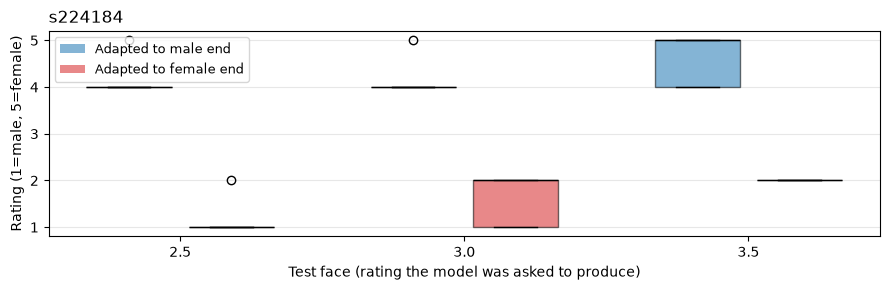

In [5]:
# This is the figure the assignment asks for: the three test faces, with the two adaptation conditions shown side by side so the shift can be read off directly.
# One row per participant, because the size of an after-effect is very personal and averaging across people can hide it.

levels = sorted(data["test_level"].unique())
colors = {MALE_END: "tab:blue", FEMALE_END: "tab:red"}
labels = {MALE_END: "Adapted to male end", FEMALE_END: "Adapted to female end"}

fig, axes = plt.subplots(len(STUDY_NRS), 1, figsize=(9, 3 * len(STUDY_NRS)), sharex=True, sharey=True)

for ax, nr in zip(np.atleast_1d(axes), STUDY_NRS):
    person = data[data["participant"] == nr]

    for offset, adaptor in [(-0.18, MALE_END), (0.18, FEMALE_END)]:
        # The two boxes for the same test face are nudged left and right of the tick, so they sit next to each other instead of on top of each other.
        boxes = [person[(person["adapting_image"] == adaptor) & (person["test_level"] == lvl)]["rating"].values
                 for lvl in levels]
        bp = ax.boxplot(boxes, positions=[i + offset for i in range(len(levels))],
                        widths=0.3, patch_artist=True, manage_ticks=False)
        for patch in bp["boxes"]:
            patch.set_facecolor(colors[adaptor])
            patch.set_alpha(0.55)
        for median in bp["medians"]:
            median.set_color("black")

    ax.set_xticks(range(len(levels)))
    ax.set_xticklabels([f"{lvl:.1f}" for lvl in levels])
    ax.set_ylabel("Rating (1=male, 5=female)")
    ax.set_title(nr, loc="left")
    ax.grid(axis="y", alpha=0.3)

handles = [plt.Rectangle((0, 0), 1, 1, facecolor=colors[a], alpha=0.55) for a in (MALE_END, FEMALE_END)]
np.atleast_1d(axes)[0].legend(handles, [labels[MALE_END], labels[FEMALE_END]], loc="upper left", fontsize=9)
np.atleast_1d(axes)[-1].set_xlabel("Test face (rating the model was asked to produce)")

plt.tight_layout()
plt.savefig("experiment3_boxplots.png", dpi=200)
plt.show()

In [6]:
# The prediction is that perception is pushed AWAY from whatever was adapted to.
# So after staring at e.g. the male end, the same test face should look more female (higher rating) than it does after staring at the female end.
# A positive difference below means the after-effect went the predicted way.

means = data.pivot_table(index=["participant", "test_level"],
                         columns="adapting_image", values="rating", aggfunc="mean")
means["difference"] = means[MALE_END] - means[FEMALE_END]
means["as predicted"] = np.where(means["difference"] > 0, "yes", "no")

print(means.round(2).to_string())
print(f"\n{(means['difference'] > 0).sum()} of {len(means)} test-face/participant combinations "
      "went in the predicted direction")

adapting_image          face_00.5.png  face_05.5.png  difference as predicted
participant test_level                                                       
s224184     2.5                   4.2            1.2         3.0          yes
            3.0                   4.2            1.6         2.6          yes
            3.5                   4.6            2.0         2.6          yes

3 of 3 test-face/participant combinations went in the predicted direction


In [ ]:
# The difference above is just a single number, and on its own it cannot tell us whether a shift of, say, 0.2 rating steps is a real after-effect or just the observer being inconsistent.
# A confidence interval answers exactly that: if the interval for the difference stays clear of zero, the shift is bigger than the wobble in the ratings can account for on its own.

# We deliberately do NOT use the usual mean +/- 1.96 * standard error formula here.
# That formula assumes the ratings are spread out in a bell shape, and ours are not - they are whole numbers from 1 to 5 that tend to pile up on a single value.
# If a participant answers "3" on all ten trials, the formula reports an interval of zero width, which would claim perfect certainty on the basis of ten identical button presses.

# Instead we bootstrap: we treat our trials as if they were the whole population, draw a new fake experiment of the same size from them, and write down the difference we get.
# Doing that 10,000 times shows how much the difference would bounce around if we ran the experiment again, and the middle 95% of those values is our interval.
# The two adaptation conditions were run as separate blocks with different trials, so we resample the two conditions independently rather than pairing trials up.


def bootstrap_difference(after_male, after_female, conf=CONF):
    """Return the observed difference in mean rating and a bootstrap confidence interval for it."""
    after_male = np.asarray(after_male, dtype=float)
    after_female = np.asarray(after_female, dtype=float)

    resampled_male = RNG.choice(after_male, size=(N_BOOT, after_male.size), replace=True).mean(axis=1)
    resampled_female = RNG.choice(after_female, size=(N_BOOT, after_female.size), replace=True).mean(axis=1)
    differences = resampled_male - resampled_female

    tail = (1 - conf) / 2
    low, high = np.quantile(differences, [tail, 1 - tail])
    return after_male.mean() - after_female.mean(), low, high


rows = []
for nr in STUDY_NRS:
    person = data[data["participant"] == nr]

    # First each test face on its own, since the assignment asks us to compare the two adaptation conditions for every test stimulus separately.
    for lvl in levels:
        face = person[person["test_level"] == lvl]
        diff, low, high = bootstrap_difference(
            face[face["adapting_image"] == MALE_END]["rating"],
            face[face["adapting_image"] == FEMALE_END]["rating"],
        )
        rows.append({"participant": nr, "test face": f"{lvl:.1f}", "difference": diff,
                     "CI low": low, "CI high": high, "trials per condition": len(face) // 2})

    # Then all three test faces pooled into a single estimate for that participant.
    # All three sit close to the neutral face and should be shifted by roughly the same amount, so pooling them triples the number of trials behind the estimate.
    # This is the honest way to get a narrower interval - it uses more data, rather than lowering the confidence level until the interval happens to look convincing.
    diff, low, high = bootstrap_difference(
        person[person["adapting_image"] == MALE_END]["rating"],
        person[person["adapting_image"] == FEMALE_END]["rating"],
    )
    rows.append({"participant": nr, "test face": "all three", "difference": diff,
                 "CI low": low, "CI high": high, "trials per condition": len(person) // 2})

shifts = pd.DataFrame(rows)
shifts["excludes zero"] = np.where((shifts["CI low"] > 0) | (shifts["CI high"] < 0), "yes", "no")

print(f"Shift in mean rating, after adapting to the male end minus after adapting to the female end, with {CONF:.0%} bootstrap CIs")
print("A positive shift is the predicted after-effect\n")
print(shifts.round(2).to_string(index=False))

Shift in mean rating, after adapting to the male end minus after adapting to the female end, with 95% bootstrap CIs
A positive shift is the predicted after-effect

participant test face  difference  CI low  CI high  trials per condition excludes zero
    s224184       2.5        3.00     2.6     3.40                     5           yes
    s224184       3.0        2.60     2.2     3.20                     5           yes
    s224184       3.5        2.60     2.2     3.00                     5           yes
    s224184 all three        2.73     2.4     3.07                    15           yes


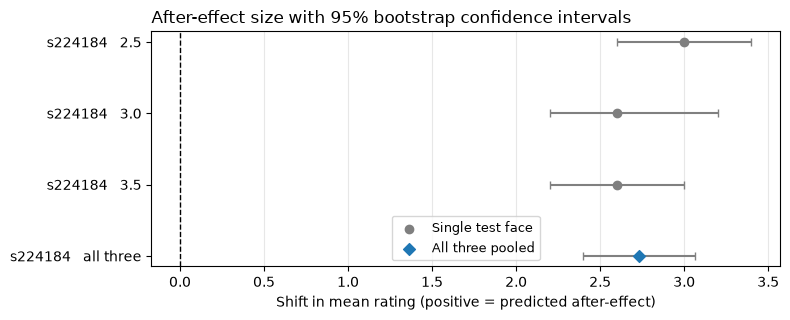

In [ ]:
# The same numbers as the table above, plotted so the dashed line at zero can be read directly - everything to the right of it went in the predicted direction, and an interval that does not touch the line is a shift we can stand behind.

fig, ax = plt.subplots(figsize=(8, 0.45 * len(shifts) + 1.5))

y = np.arange(len(shifts))[::-1]  # reversed so the first participant ends up at the top of the figure
pooled = (shifts["test face"] == "all three").values

ax.errorbar(shifts["difference"], y,
            xerr=[shifts["difference"] - shifts["CI low"], shifts["CI high"] - shifts["difference"]],
            fmt="none", ecolor="gray", capsize=3)
ax.scatter(shifts["difference"][~pooled], y[~pooled], color="tab:gray", zorder=3, label="Single test face")
ax.scatter(shifts["difference"][pooled], y[pooled], color="tab:blue", zorder=3, marker="D", label="All three pooled")

ax.axvline(0, linestyle="--", color="black", linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels([f"{row.participant}   {row._2}" for row in shifts.itertuples()])
ax.set_xlabel("Shift in mean rating (positive = predicted after-effect)")
ax.set_title(f"After-effect size with {CONF:.0%} bootstrap confidence intervals", loc="left")
ax.legend(fontsize=9)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("experiment3_shifts.png", dpi=200)
plt.show()

In [ ]:
# A second opinion on the same question, using a test that only looks at the order of the ratings and never treats them as numbers.

for nr in STUDY_NRS:
    person = data[data["participant"] == nr]
    after_male = person[person["adapting_image"] == MALE_END]["rating"]
    after_female = person[person["adapting_image"] == FEMALE_END]["rating"]

    # 'greater' because we are testing the specific prediction that adapting to the male end pushes ratings upwards, not just that the two conditions differ in some way.
    stat, p = mannwhitneyu(after_male, after_female, alternative="greater")
    print(f"{nr}: {after_male.mean():.2f} vs {after_female.mean():.2f}, "
          f"shift = {after_male.mean() - after_female.mean():+.2f}, one-sided p = {p:.3f}")

s224184: 4.33 vs 1.60, shift = +2.73, one-sided p = 0.000
